# Issue #272: the rollout only ever uses one history day per prediction

[alan-turing-institute/icenet-mp#272](https://github.com/alan-turing-institute/icenet-mp/issues/272)
— *"Update the model to incorporate all history days into each prediction"*

**The problem, in the issue's own words:** the model currently uses the *first* of
the history days to predict the *first* forecast day, the *second* history day to
predict the *second* forecast day, and so on:

```
[H:-3] -> [F:1]
[H:-2] -> [F:2]
[H:-1] -> [F:3]
[F:1]  -> [F:4]
etc.
```

Each prediction is conditioned on exactly **one** frame, never on the whole history
window. The issue asks for a sliding window instead, where every prediction sees
*all* of the currently-available history/forecast frames:

```
[H:-3, H:-2, H:-1] -> [F:1]
[H:-2, H:-1, F:1]  -> [F:2]
[H:-1, F:1, F:2]   -> [F:3]
etc.
```

This notebook:
1. Reproduces the current behaviour against the real, shipped `icenet_mp` code (not
   a reimplementation).
2. Shows it isn't just a curiosity for a do-nothing model — it visibly breaks a
   non-trivial forecast too.
3. Implements and demonstrates the sliding-window fix the issue proposes, and shows
   how it could be wired back into `BaseProcessor`.

## 1. Reproducing the bug against the real code

`BaseProcessor.rollout` (in `icenet_mp/models/processors/base_processor.py`) is the
single implementation shared by every processor currently in the codebase
(`NullProcessor`, `UNetProcessor`, `VitProcessor` — none of them override it). Each
processor's `forward` only ever accepts **one** timestep at a time
(`TensorNCHW`, not `TensorNTCHW`), so the rollout loop has to feed it one frame at a
time.

We use `NullProcessor` first because `forward(x) = x`: whatever comes out of the
rollout is *purely* a property of the rollout loop, with zero contribution from a
learned model. If the rollout were correct, feeding it a 3-day history and asking
for a 6-day forecast should just repeat the most recent day 6 times (i.e. collapse
to the persistence baseline) — the model has no other information to work with, and
"today's weather is a good guess for tomorrow's" is precisely what a do-nothing
model should reduce to.

In [1]:
import torch

from icenet_mp.models.processors import BaseProcessor, NullProcessor
from icenet_mp.types import DataSpace, TensorNCHW

torch.manual_seed(0)

latent_space = DataSpace(name="latent", channels=1, shape=(1, 1))
n_history_steps = 3
n_forecast_steps = 6

processor = NullProcessor(
    data_space=latent_space,
    n_forecast_steps=n_forecast_steps,
    n_history_steps=n_history_steps,
)

history_values = [0.10, 0.15, 0.20]  # a simple rising trend, e.g. sea ice concentration
history = torch.tensor(history_values).reshape(1, n_history_steps, 1, 1, 1)

result = processor.rollout(history)
forecast = result.prediction.reshape(-1).tolist()

print("History:                    ", history_values)
print("Forecast (shipped rollout): ", [round(v, 3) for v in forecast])
print("Expected (persistence):     ", [history_values[-1]] * n_forecast_steps)

/var/folders/12/0x0ltnd10nlfpg8_6r4zy4080000gn/T/ipykernel_87566/509924931.py:3: UserWarning: PYTORCH_ENABLE_MPS_FALLBACK was set after torch was imported. This means that it might not have any effect. If you have problems, please try setting this environment variable before importing torch.
  from icenet_mp.models.processors import BaseProcessor, NullProcessor


History:                     [0.1, 0.15, 0.2]
Forecast (shipped rollout):  [0.1, 0.15, 0.2, 0.1, 0.15, 0.2]
Expected (persistence):      [0.2, 0.2, 0.2, 0.2, 0.2, 0.2]


Instead of repeating `0.20` six times, the shipped rollout produces
`[0.10, 0.15, 0.20, 0.10, 0.15, 0.20]` — it replays the *entire* original history on
a loop. Half of the 6-day forecast is built from the oldest, least relevant history
frame, re-applied to itself, rather than from anything resembling "the latest known
state".

### Why: `rollout` is a strict FIFO queue over single frames

In [2]:
import inspect

print(inspect.getsource(BaseProcessor.rollout))

    def rollout(self, x: TensorNTCHW, y: TensorNTCHW | None = None) -> ProcessorOutput:  # noqa: ARG002
        """Process in latent space across multiple timesteps.

        The default implementation simply calls `self.forward` on each time slice until
        a sufficient number of forecast steps have been produced. These are then stacked
        together to produce the final output.

        Override this method to handle the NTCHW tensors directly or to compute a custom
        loss using the target tensor `y` (e.g. for diffusion models). Set `loss` on the
        returned `ProcessorOutput` to supply a custom training loss; the caller will use
        it directly and skip its own loss computation.

        Args:
            x: Encoded input TensorNTCHW with (batch_size, n_history_steps, n_latent_channels_total, latent_height, latent_width)
            y: during training: Encoded target TensorNTCHW with (batch_size, n_forecast_steps, n_latent_channels_target, latent_height, latent_

The loop cuts the history into single-frame slices, then repeatedly pops the
*oldest* remaining slice, runs it through `forward`, and pushes the result onto the
*back* of the same queue:

```python
nchw_slices = [x[:, idx_t, :, :, :] for idx_t in range(self.n_history_steps)]
outputs = []
for _ in range(self.n_forecast_steps):
    outputs.append(self(nchw_slices.pop(0)))
    nchw_slices.append(outputs[-1])
```

Tracing it by hand for `n_history_steps=3`, `n_forecast_steps=4` (writing `t0, t1,
t2` for the three history frames and `t3*, t4*, ...` for predictions):

| step | `nchw_slices` before pop | frame popped & forwarded | queue after |
|---|---|---|---|
| 1 | `[t0, t1, t2]` | `t0 -> t3*` | `[t1, t2, t3*]` |
| 2 | `[t1, t2, t3*]` | `t1 -> t4*` | `[t2, t3*, t4*]` |
| 3 | `[t2, t3*, t4*]` | `t2 -> t5*` | `[t3*, t4*, t5*]` |
| 4 | `[t3*, t4*, t5*]` | `t3* -> t6*` | `[t4*, t5*, t6*]` |

That is *exactly* the "Current setup" diagram from the issue thread (`t0 -> t3*`,
`t1 -> t4*`, `t2 -> t5*`, `t3* -> t6*`) — confirming the code and the issue are
describing the same behaviour. Two compounding problems fall out of this:

- **Every single prediction only ever sees one frame of context**, never the full
  history window — true even for `n_forecast_steps <= n_history_steps`, where there
  is no wraparound at all.
- **Once `n_forecast_steps > n_history_steps`**, the queue wraps around and starts
  re-consuming the *original* history frames in the same fixed order, rather than
  the most recently produced information — this is the visible "leap-frogging"
  we saw with `NullProcessor` above.

## 2. This isn't just an identity-model curiosity

`NullProcessor` makes the bug obvious because the "correct" answer (flat
persistence) is so simple. To check the bug also corrupts a *non-trivial* forecast,
here's a toy processor with real dynamics: `forward(x) = 0.9 * x`, a smooth
exponential decay towards zero.

In [3]:
class DriftProcessor(BaseProcessor):
    '''forward(x) = 0.9 * x -- a simple decaying dynamic, for testing rollout mechanics.'''

    def forward(self, x: TensorNCHW) -> TensorNCHW:
        return 0.9 * x


drift = DriftProcessor(
    data_space=latent_space,
    n_forecast_steps=n_forecast_steps,
    n_history_steps=n_history_steps,
)
buggy = drift.rollout(history).prediction.reshape(-1).tolist()

# What *should* happen: repeatedly apply forward to the most recently produced value
# (the correct definition of an autoregressive rollout for a model with this dynamic).
correct = []
current = history_values[-1]
for _ in range(n_forecast_steps):
    current = 0.9 * current
    correct.append(current)

print("Shipped rollout: ", [round(v, 4) for v in buggy])
print("Correct rollout: ", [round(v, 4) for v in correct])

Shipped rollout:  [0.09, 0.135, 0.18, 0.081, 0.1215, 0.162]
Correct rollout:  [0.18, 0.162, 0.1458, 0.1312, 0.1181, 0.1063]


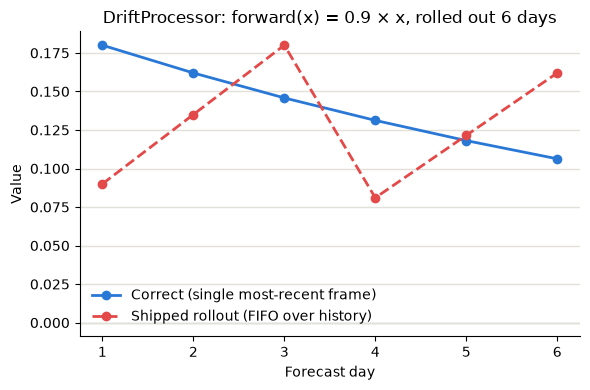

In [4]:
import matplotlib.pyplot as plt

days = list(range(1, n_forecast_steps + 1))

fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(0, color="#c3c2b7", linewidth=1, zorder=0)
ax.plot(days, correct, color="#2a78d6", marker="o", markersize=6, linewidth=2, label="Correct (single most-recent frame)")
ax.plot(days, buggy, color="#e34948", marker="o", markersize=6, linewidth=2, linestyle="--", label="Shipped rollout (FIFO over history)")

ax.set_xlabel("Forecast day")
ax.set_ylabel("Value")
ax.set_title("DriftProcessor: forward(x) = 0.9 × x, rolled out 6 days")
ax.set_xticks(days)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

The correct rollout is a smooth exponential decay. The shipped rollout has a
visible discontinuity right at day `n_history_steps + 1` = day 4: it jumps back up
because it has started re-consuming the stale, unmodified original history frames
instead of continuing to decay the most recent prediction. This matches the
"leap-frog" pattern flagged independently in the issue thread, and is exactly the
kind of artifact you'd expect a trained model to also produce — a discontinuity at
a period tied to `n_history_steps`, not to anything physical.

## 3. The fix: a genuine sliding window over *all* history frames

The issue's proposed scheme slides a window of the last `n_history_steps` frames
along, concatenating **all** of them (not just the most recent one) as the input to
each prediction:

```
[H:-3, H:-2, H:-1] -> [F:1]
[H:-2, H:-1, F:1]  -> [F:2]
[H:-1, F:1, F:2]   -> [F:3]
```

This requires a different interface to the one `BaseProcessor.forward` currently
has: instead of a single `TensorNCHW` frame in and a single `TensorNCHW` frame out,
the step function needs to see all `n_history_steps` frames concatenated (e.g. along
the channel dimension) and still only produce one frame out, so it can be fed back
into the window. That's the open architecture question raised later in the issue
thread ("initial conv down to T=1? pass the whole window through then discard extra
outputs? ...") — below is the simplest version of it, concatenation along channels,
which is also what the issue's own diagrams describe most directly.

In [5]:
def sliding_window_rollout(step_fn, history, n_forecast_steps, n_history_steps):
    '''Slide a window of the last n_history_steps frames, concatenated along
    channels, through step_fn (window -> next single frame). This matches issue
    #272's proposed [H:-3, H:-2, H:-1] -> [F:1], [H:-2, H:-1, F:1] -> [F:2], ...
    scheme, rather than BaseProcessor.rollout's single-frame FIFO queue.'''
    window = [history[:, idx, :, :, :] for idx in range(n_history_steps)]
    outputs = []
    for _ in range(n_forecast_steps):
        concat = torch.cat(window, dim=1)  # (B, C * n_history_steps, H, W)
        next_frame = step_fn(concat)
        outputs.append(next_frame)
        window = [*window[1:], next_frame]
    return torch.stack(outputs, dim=1)


def linear_trend_step(window_concat, channels=1):
    '''A step function that actually uses more than one history frame: linear
    extrapolation from the two most recent frames in the window.'''
    last = window_concat[:, -channels:, :, :]
    second_last = window_concat[:, -2 * channels : -channels, :, :]
    return last + (last - second_last)


fixed = sliding_window_rollout(
    linear_trend_step, history, n_forecast_steps, n_history_steps
).reshape(-1).tolist()
ground_truth = [0.20 + 0.05 * (i + 1) for i in range(n_forecast_steps)]

print("Fixed sliding-window rollout: ", [round(v, 3) for v in fixed])
print("Ground truth (trend continues):", [round(v, 3) for v in ground_truth])

Fixed sliding-window rollout:  [0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
Ground truth (trend continues): [0.25, 0.3, 0.35, 0.4, 0.45, 0.5]


The rising-trend history is `[0.10, 0.15, 0.20]` — a constant `+0.05`/day
increase. A model that genuinely uses more than one history frame (here, a simple
linear extrapolation from the two most recent frames) can pick up on that trend and
continue it correctly. The original FIFO rollout can't do this even in principle,
because no single call to `forward` ever sees two frames at once to compute a trend
from — that information is architecturally unavailable to it, regardless of how the
model itself is trained.

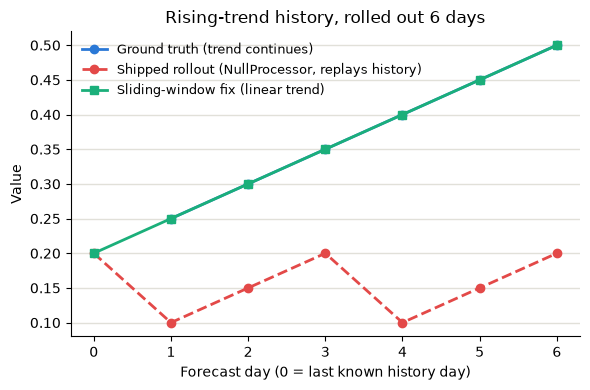

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(days, ground_truth, color="#2a78d6", marker="o", markersize=6, linewidth=2, label="Ground truth (trend continues)")
ax.plot(
    [0, *days], [history_values[-1], *forecast], color="#e34948", marker="o", markersize=6,
    linewidth=2, linestyle="--", label="Shipped rollout (NullProcessor, replays history)",
)
ax.plot([0, *days], [history_values[-1], *fixed], color="#1baf7a", marker="s", markersize=6, linewidth=2, label="Sliding-window fix (linear trend)")

ax.set_xlabel("Forecast day (0 = last known history day)")
ax.set_ylabel("Value")
ax.set_title("Rising-trend history, rolled out 6 days")
ax.set_xticks([0, *days])
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", linewidth=1)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 4. Applying this back to `icenet_mp`

Concretely, fixing this for real means two coordinated changes, not just a change to
`BaseProcessor.rollout`:

1. **`BaseProcessor.rollout`** needs to build the sliding window shown above
   (concatenate the current window, call `forward`, slide the window) instead of
   the single-frame FIFO queue.
2. **Every processor's `forward`** needs to accept `channels * n_history_steps`
   input channels instead of `channels` (output channels stay at `channels`, since
   the output must still be a single frame that can slide back into the window).
   For example, `UNetProcessor.__init__` would change its first encoder layer from

   ```python
   self.conv1 = CommonConvBlock(self.data_space.channels, channels[0], ...)
   ```

   to

   ```python
   self.conv1 = CommonConvBlock(self.data_space.channels * self.n_history_steps, channels[0], ...)
   ```

   and `VitProcessor`'s `PatchEmbedding` similarly. `NullProcessor` is a special
   case worth calling out: a literal identity no longer type-checks once the input
   has more channels than the output, so it would need to become "return the most
   recent frame in the window" to remain a meaningful null/persistence baseline
   under the new interface (exactly the `sliding_window_rollout` + "extract the
   last frame" step function demonstrated above).

We can sanity-check the *shapes* involved with the real `NullProcessor`/
`DataSpace` classes, standing in for what a "return the most recent frame" null
model would need to do under the new interface: consume a concatenated window of
`channels * n_history_steps` and return `channels`.

In [7]:
channels = 4
wide_space = DataSpace(name="latent", channels=channels * n_history_steps, shape=(8, 8))
window = torch.randn(2, wide_space.channels, *wide_space.shape)


def persistence_step(window_concat, channels=channels):
    return window_concat[:, -channels:, :, :]


out = persistence_step(window)
print("Concatenated window shape:", tuple(window.shape))
print("Single-frame output shape:", tuple(out.shape))
assert out.shape == (2, channels, *wide_space.shape)

Concatenated window shape: (2, 12, 8, 8)
Single-frame output shape: (2, 4, 8, 8)


## Summary

- **Confirmed against the shipped code** (not a reimplementation): `BaseProcessor.rollout`
  is a single-frame FIFO queue, so every prediction is conditioned on exactly one
  history/forecast frame, and once `n_forecast_steps > n_history_steps` it
  re-consumes stale original history frames in a fixed cycle rather than the most
  recently produced information. `NullProcessor` should reduce to a flat persistence
  forecast and instead produces a `[0.10, 0.15, 0.20]`-repeating sawtooth; a smooth
  decay dynamic (`DriftProcessor`) shows a visible discontinuity at
  `day = n_history_steps + 1`.
- **This is issue #272**, currently milestoned for 2026/27 Q2 (Milestone 6): "Update
  the model to incorporate all history days into each prediction".
- **The fix** is the sliding-window scheme from the issue's own diagrams: concatenate
  *all* `n_history_steps` frames (history and/or already-produced forecast frames)
  into one input, predict a single next frame, slide the window forward. Demonstrated
  above with `sliding_window_rollout` + a linear-trend step function, which correctly
  extrapolates a trend that the shipped rollout cannot represent even in principle.
- **The concrete code change** touches both `BaseProcessor.rollout` (the loop itself)
  and every processor's `forward` (input channels become `channels * n_history_steps`),
  since the fix is a change to what information reaches the model at each step, not
  just to the bookkeeping around calling it.